100.0%
100.0%
100.0%
100.0%
/Users/traver/Desktop/MQP 2025/venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | SDAE train_MSE=0.0671 test_MSE=0.0628 (k_train=3, k_eval=3) | DAE  train_MSE=0.0630  test_MSE=0.0473 | AE   train_MSE=0.0436   test_MSE=0.0228
Epoch 02 | SDAE train_MSE=0.0597 test_MSE=0.0586 (k_train=3, k_eval=3) | DAE  train_MSE=0.0407  test_MSE=0.0359 | AE   train_MSE=0.0189   test_MSE=0.0151
Epoch 03 | SDAE train_MSE=0.0555 test_MSE=0.0540 (k_train=3, k_eval=3) | DAE  train_MSE=0.0346  test_MSE=0.0325 | AE   train_MSE=0.0137   test_MSE=0.0122
Epoch 04 | SDAE train_MSE=0.0516 test_MSE=0.0509 (k_train=3, k_eval=3) | DAE  train_MSE=0.0316  test_MSE=0.0302 | AE   train_MSE=0.0114   test_MSE=0.0103
Epoch 05 | SDAE train_MSE=0.0486 test_MSE=0.0459 (k_train=3, k_eval=3) | DAE  train_MSE=0.0297  test_MSE=0.0282 | AE   train_MSE=0.0099   test_MSE=0.0091
Epoch 06 | SDAE train_MSE=0.0450 test_MSE=0.0433 (k_train=3, k_eval=3) | DAE  train_MSE=0.0282  test_MSE=0.0273 | AE   train_MSE=0.0088   test_MSE=0.0083
Epoch 07 | SDAE train_MSE=0.0420 test_MSE=0.0400 (k_train=3, k_eval=3) | DAE

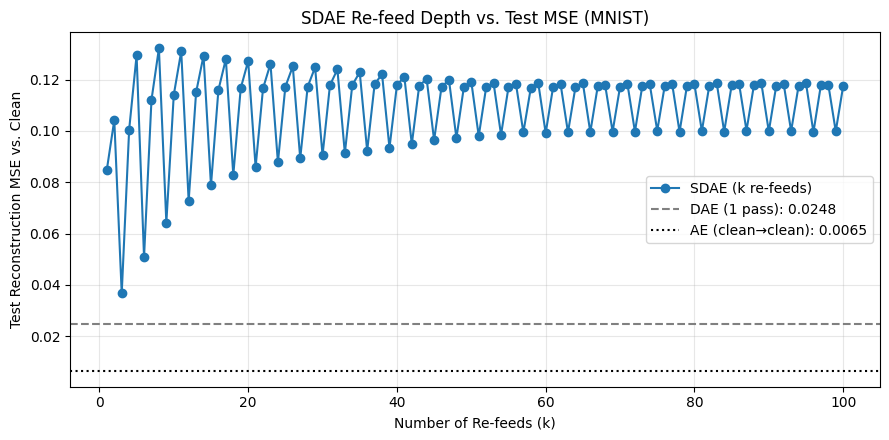

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from typing import Dict, List

# ----------------------------
# Noise
# ----------------------------
def add_noise(img, noise_factor=0.81):
    """
    Add Gaussian noise to an input image tensor in [0,1], then clamp.
    """
    noisy = img + noise_factor * torch.randn_like(img)
    return torch.clamp(noisy, 0., 1.)

# ----------------------------
# Data
# ----------------------------
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# ----------------------------
# Model
# ----------------------------
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# ----------------------------
# Utilities
# ----------------------------
def forward_k(model: nn.Module, x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Feed 'x' through 'model' k times (re-feeds).
    """
    for _ in range(k):
        x = model(x)
    return x

@torch.no_grad()
def batch_mse(a, b):
    return ((a - b) ** 2).mean().item()

def evaluate(model: nn.Module,
             loader,
             *,
             denoising: bool,
             re_feeds: int = 1,
             noise_factor: float = 0.81,
             device: torch.device = torch.device("cpu"),
             criterion = nn.MSELoss()) -> float:
    """
    Evaluate reconstruction MSE against the clean target images.
    - If denoising=True, inputs = add_noise(clean), targets = clean.
    - If denoising=False, inputs = clean, targets = clean.
    - The model output is forward_k(model, inputs, re_feeds).
    """
    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device, non_blocking=True)
            inputs = add_noise(imgs, noise_factor) if denoising else imgs
            recon = forward_k(model, inputs, re_feeds)
            loss = criterion(recon, imgs)
            bsz = imgs.size(0)
            total += loss.item() * bsz
            count += bsz
    return total / max(count, 1)

# ----------------------------
# Setup 3 models
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Stacked denoising AE (SDAE): trained with k>1 re-feeds on noisy inputs
sdae = DenoisingAutoencoder().to(device)

# 2) Single-pass denoising AE (DAE): trained 1 pass on noisy inputs
dae  = DenoisingAutoencoder().to(device)

# 3) Plain AE: trained 1 pass on clean inputs
ae   = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
opt_sdae = optim.Adam(sdae.parameters(), lr=1e-3)
opt_dae  = optim.Adam(dae.parameters(),  lr=1e-3)
opt_ae   = optim.Adam(ae.parameters(),   lr=1e-3)

noise_factor = 0.81
epochs = 10
stack_k_train = 3     # SDAE training re-feeds
stack_k_eval  = 3     # SDAE default eval re-feeds

# ----------------------------
# Training loop
# ----------------------------
for epoch in range(1, epochs + 1):
    sdae.train(); dae.train(); ae.train()
    train_sum = {"sdae":0.0, "dae":0.0, "ae":0.0}
    train_cnt = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        noisy = add_noise(imgs, noise_factor)

        bsz = imgs.size(0)

        # ---- SDAE: noisy -> clean with k re-feeds
        x = forward_k(sdae, noisy, stack_k_train)
        loss_sdae = criterion(x, imgs)
        opt_sdae.zero_grad(set_to_none=True)
        loss_sdae.backward()
        opt_sdae.step()

        # ---- DAE: noisy -> clean with 1 pass
        out_dae = dae(noisy)
        loss_dae = criterion(out_dae, imgs)
        opt_dae.zero_grad(set_to_none=True)
        loss_dae.backward()
        opt_dae.step()

        # ---- AE: clean -> clean with 1 pass
        out_ae = ae(imgs)
        loss_ae = criterion(out_ae, imgs)
        opt_ae.zero_grad(set_to_none=True)
        loss_ae.backward()
        opt_ae.step()

        train_sum["sdae"] += loss_sdae.item() * bsz
        train_sum["dae"]  += loss_dae.item()  * bsz
        train_sum["ae"]   += loss_ae.item()   * bsz
        train_cnt         += bsz

    # ---- Eval in natural regimes
    sdae_test = evaluate(sdae, test_loader, denoising=True,  re_feeds=stack_k_eval, noise_factor=noise_factor, device=device, criterion=criterion)
    dae_test  = evaluate(dae,  test_loader, denoising=True,  re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)
    ae_test   = evaluate(ae,   test_loader, denoising=False, re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)

    print(
        f"Epoch {epoch:02d} | "
        f"SDAE train_MSE={train_sum['sdae']/train_cnt:.4f} test_MSE={sdae_test:.4f} (k_train={stack_k_train}, k_eval={stack_k_eval}) | "
        f"DAE  train_MSE={train_sum['dae']/train_cnt:.4f}  test_MSE={dae_test:.4f} | "
        f"AE   train_MSE={train_sum['ae']/train_cnt:.4f}   test_MSE={ae_test:.4f}"
    )

# ----------------------------
# Iterative re-feed sweep for SDAE (k=1..100), with baselines
# ----------------------------
sdae.eval(); dae.eval(); ae.eval()

@torch.no_grad()
def sdae_k_sweep_mse(model: nn.Module,
                     loader,
                     ks: List[int],
                     noise_factor: float,
                     device: torch.device,
                     criterion = nn.MSELoss()) -> Dict[int, float]:
    """
    Compute test MSE for each k re-feeds on the *same* test set, denoising mode.
    Returns dict {k: mse}.
    """
    results = {}
    for k in ks:
        mse_k = evaluate(model, loader, denoising=True, re_feeds=k,
                         noise_factor=noise_factor, device=device, criterion=criterion)
        results[k] = mse_k
    return results

# Baseline reference (single numbers)
dae_mse  = evaluate(dae, test_loader, denoising=True,  re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)
ae_mse   = evaluate(ae,  test_loader, denoising=False, re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)

ks = list(range(1, 101))
sdae_curve = sdae_k_sweep_mse(sdae, test_loader, ks, noise_factor, device, criterion)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(ks, [sdae_curve[k] for k in ks], marker='o', linestyle='-', label='SDAE (k re-feeds)')
plt.axhline(dae_mse, color='gray', linestyle='--', label=f'DAE (1 pass): {dae_mse:.4f}')
plt.axhline(ae_mse,  color='black', linestyle=':',  label=f'AE (clean→clean): {ae_mse:.4f}')
plt.xlabel('Number of Re-feeds (k)')
plt.ylabel('Test Reconstruction MSE vs. Clean')
plt.title('SDAE Re-feed Depth vs. Test MSE (MNIST)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: quick sample visualization of denoising
# ----------------------------
@torch.no_grad()
def visualize_examples(model_sdae, model_dae, model_ae, loader, k_sdae=3, noise_factor=0.81, num_show=8):
    imgs, _ = next(iter(loader))
    imgs = imgs[:num_show].to(device)
    noisy = add_noise(imgs, noise_factor)

    deno_sdae = forward_k(model_sdae, noisy, k_sdae)
    deno_dae  = model_dae(noisy)
    recon_ae  = model_ae(imgs)

    # grid: clean | noisy | SDAE | DAE | AE (for reference)
    grid = torch.cat([imgs.cpu(), noisy.cpu(), deno_sdae.cpu(), deno_dae.cpu(), recon_ae.cpu()], dim=0)
    grid = make_grid(grid, nrow=num_show, pad_value=1.0)
    plt.figure(figsize=(num_show * 1.2, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"SDAE k={k_sdae} | DAE 1-pass | AE 1-pass")
    plt.show()

# Uncomment to visualize
# visualize_examples(sdae, dae, ae, test_loader, k_sdae=stack_k_eval, noise_factor=noise_factor, num_show=8)

In [3]:
from typing import List, Tuple

def trajectory(model: nn.Module, x0: torch.Tensor, k: int):
    """
    Iterative trajectory: y1 = f*x0), yk = f(k-1).
    Returns [y1, y2, ..., yk] 
    """
    
    ys = []
    y = model(x0)
    ys.append(y)
    for _ in range(1,k):
        y = model(y)
        ys.append(y)
    return ys

def iterative_loss(
    ys: List[torch.Tensor],
    x_target: torch.Tensor,
    *,
    w_rec: torch.Tensor,
    lambda_stay = float(1.0),
    eps: float = 1e-3,
    smooth_tau: float = 20.00):
    
    """
    L_rec = sum(t = 1,... k) w_t * ||y_t - x || ^ 2
    L_stay = sum(t = 1... k-1) lambda_stay * 1[||y_t - x || ^ 2 < epsilon] * ||y_t+1 = y_t||^2
    Returns (total_loss, metrics) Which reduces over batch by the mean.
    """
    device = x_target.device
    dtype = x_target.dtype
    k = len(ys)
    assert w_rec.numel() == k 

    # L_rec
    rec_terms = []
    for wt, yt in zip(w_rec, ys):
        d2 = (yt - x_target).pow(2).flatten(1).sum(dim = 1)
        rec_terms.append(wt*d2)
    L_rec_per_ex = torch.stack(rec_terms, dim = 1).sum(dim=1)
    L_rec = L_rec_per_ex.mean()

    stay_terms = []
    eps_t = torch.as_tensor(eps, device = device, dtype = dtype)
    for t in range(k-1):
        yt, t_t1 = ys[t], ys[t+1]
        dtx2 = (yt - x_target).pow(2).flatten(1).sum(dim = 1)
        if smooth_tau is None:
            ind = (dtx2 < eps_t).float()
        else:
            tau = torch.as_tensor(smooth_tau, device = device, dtype = dtype)
            ind = torch.sigmoid(tau * (eps_t - dtx2))
        step2 = (yt-yt).pow(2).flatten(1).sum(dim=1)
        stay_terms.append(ind * step2)

    if stay_terms:
        L_stay_per_ex = torch.stack(stay_terms, dim = 1).sum(dim=1)
        L_stay = (lambda_stay * L_stay_per_ex).mean()
        mean_ind = torch.stack(stay_terms, dim = 1).mean().detach()
    else:
        L_stay = torch.zeros((), device = device, dtype = dtype)
        mean_ind = torch.tensor(0.0)

    total = L_rec + L_stay
    metrics = {
        "loss_total": total.detach(),
        "loss_rec": L_rec.detach(),
        "loss_stay": L_stay.detach(),
        "mean_indicator": mean_ind}
        
    return total, metrics

/Users/traver/Desktop/MQP 2025/venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | SDAE train_MSE=0.0683 test_MSE=0.0613 (k_train=3, k_eval=3) | DAE  train_MSE=0.0614  test_MSE=0.0444 | AE   train_MSE=0.0453   test_MSE=0.0248
Epoch 02 | SDAE train_MSE=0.0577 test_MSE=0.0529 (k_train=3, k_eval=3) | DAE  train_MSE=0.0392  test_MSE=0.0357 | AE   train_MSE=0.0203   test_MSE=0.0166
Epoch 03 | SDAE train_MSE=0.0484 test_MSE=0.0442 (k_train=3, k_eval=3) | DAE  train_MSE=0.0340  test_MSE=0.0318 | AE   train_MSE=0.0147   test_MSE=0.0127
Epoch 04 | SDAE train_MSE=0.0426 test_MSE=0.0401 (k_train=3, k_eval=3) | DAE  train_MSE=0.0311  test_MSE=0.0299 | AE   train_MSE=0.0119   test_MSE=0.0108
Epoch 05 | SDAE train_MSE=0.0395 test_MSE=0.0376 (k_train=3, k_eval=3) | DAE  train_MSE=0.0294  test_MSE=0.0281 | AE   train_MSE=0.0103   test_MSE=0.0095
Epoch 06 | SDAE train_MSE=0.0374 test_MSE=0.0363 (k_train=3, k_eval=3) | DAE  train_MSE=0.0281  test_MSE=0.0272 | AE   train_MSE=0.0091   test_MSE=0.0084
Epoch 07 | SDAE train_MSE=0.0360 test_MSE=0.0348 (k_train=3, k_eval=3) | DAE

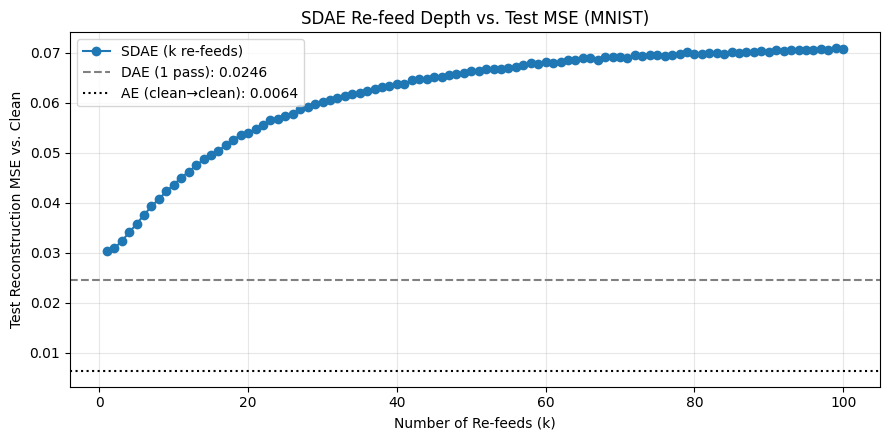

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from typing import Dict, List

# ----------------------------
# Noise
# ----------------------------
def add_noise(img, noise_factor=0.81):
    """
    Add Gaussian noise to an input image tensor in [0,1], then clamp.
    """
    noisy = img + noise_factor * torch.randn_like(img)
    return torch.clamp(noisy, 0., 1.)

# ----------------------------
# Data
# ----------------------------
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# ----------------------------
# Model
# ----------------------------
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# ----------------------------
# Utilities
# ----------------------------
def forward_k(model: nn.Module, x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Feed 'x' through 'model' k times (re-feeds).
    """
    for _ in range(k):
        x = model(x)
    return x

@torch.no_grad()
def batch_mse(a, b):
    return ((a - b) ** 2).mean().item()

def evaluate(model: nn.Module,
             loader,
             *,
             denoising: bool,
             re_feeds: int = 1,
             noise_factor: float = 0.81,
             device: torch.device = torch.device("cpu"),
             criterion = nn.MSELoss()) -> float:
    """
    Evaluate reconstruction MSE against the clean target images.
    - If denoising=True, inputs = add_noise(clean), targets = clean.
    - If denoising=False, inputs = clean, targets = clean.
    - The model output is forward_k(model, inputs, re_feeds).
    """
    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device, non_blocking=True)
            inputs = add_noise(imgs, noise_factor) if denoising else imgs
            recon = forward_k(model, inputs, re_feeds)
            loss = criterion(recon, imgs)
            bsz = imgs.size(0)
            total += loss.item() * bsz
            count += bsz
    return total / max(count, 1)

# ----------------------------
# Setup 3 models
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Stacked denoising AE (SDAE): trained with k>1 re-feeds on noisy inputs
sdae = DenoisingAutoencoder().to(device)

# 2) Single-pass denoising AE (DAE): trained 1 pass on noisy inputs
dae  = DenoisingAutoencoder().to(device)

# 3) Plain AE: trained 1 pass on clean inputs
ae   = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
opt_sdae = optim.Adam(sdae.parameters(), lr=1e-3)
opt_dae  = optim.Adam(dae.parameters(),  lr=1e-3)
opt_ae   = optim.Adam(ae.parameters(),   lr=1e-3)

noise_factor = 0.81
epochs = 10
stack_k_train = 3     # SDAE training re-feeds
stack_k_eval  = 3     # SDAE default eval re-feeds

# Iterative loss hyperparams (SDAE only)
lambda_stay = 0.5
stay_eps    = 1e-2
smooth_tau  = 20.0          # set None for a hard indicator
# Uniform weights across k training steps
# w_rec_sdae = torch.ones(stack_k_train, device=device)
# or emphasize later steps:
w_rec_sdae = torch.linspace(0.75, 1.25, steps=stack_k_train, device=device)



# ----------------------------
# Training loop
# ----------------------------
for epoch in range(1, epochs + 1):
    sdae.train(); dae.train(); ae.train()
    train_sum = {"sdae":0.0, "dae":0.0, "ae":0.0}
    train_cnt = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        noisy = add_noise(imgs, noise_factor)

        bsz = imgs.size(0)

        # ---- SDAE: noisy -> clean with k re-feeds
        ys_sdae = trajectory(sdae, noisy, stack_k_train)  # [y1,...,yk]
        loss_sdae, sdae_metrics = iterative_loss(
            ys_sdae, imgs,
            w_rec=w_rec_sdae,
            lambda_stay=lambda_stay,
            eps=stay_eps,
            smooth_tau=smooth_tau,
        )
        opt_sdae.zero_grad(set_to_none=True)
        loss_sdae.backward()
        opt_sdae.step()
        
        # For apples-to-apples train logging (MSE of final iterate vs clean)
        sdae_last = ys_sdae[-1].detach()
        loss_sdae_mse = criterion(sdae_last, imgs)


        # ---- DAE: noisy -> clean with 1 pass
        out_dae = dae(noisy)
        loss_dae = criterion(out_dae, imgs)
        opt_dae.zero_grad(set_to_none=True)
        loss_dae.backward()
        opt_dae.step()

        # ---- AE: clean -> clean with 1 pass
        out_ae = ae(imgs)
        loss_ae = criterion(out_ae, imgs)
        opt_ae.zero_grad(set_to_none=True)
        loss_ae.backward()
        opt_ae.step()

        train_sum["sdae"] += loss_sdae_mse.item() * bsz
        train_sum["dae"]  += loss_dae.item()  * bsz
        train_sum["ae"]   += loss_ae.item()   * bsz
        train_cnt         += bsz

    # ---- Eval in natural regimes
    sdae_test = evaluate(sdae, test_loader, denoising=True,  re_feeds=stack_k_eval, noise_factor=noise_factor, device=device, criterion=criterion)
    dae_test  = evaluate(dae,  test_loader, denoising=True,  re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)
    ae_test   = evaluate(ae,   test_loader, denoising=False, re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)

    print(
        f"Epoch {epoch:02d} | "
        f"SDAE train_MSE={train_sum['sdae']/train_cnt:.4f} test_MSE={sdae_test:.4f} (k_train={stack_k_train}, k_eval={stack_k_eval}) | "
        f"DAE  train_MSE={train_sum['dae']/train_cnt:.4f}  test_MSE={dae_test:.4f} | "
        f"AE   train_MSE={train_sum['ae']/train_cnt:.4f}   test_MSE={ae_test:.4f}"
    )

# ----------------------------
# Iterative re-feed sweep for SDAE (k=1..100), with baselines
# ----------------------------
sdae.eval(); dae.eval(); ae.eval()

@torch.no_grad()
def sdae_k_sweep_mse(model: nn.Module,
                     loader,
                     ks: List[int],
                     noise_factor: float,
                     device: torch.device,
                     criterion = nn.MSELoss()) -> Dict[int, float]:
    """
    Compute test MSE for each k re-feeds on the *same* test set, denoising mode.
    Returns dict {k: mse}.
    """
    results = {}
    for k in ks:
        mse_k = evaluate(model, loader, denoising=True, re_feeds=k,
                         noise_factor=noise_factor, device=device, criterion=criterion)
        results[k] = mse_k
    return results

# Baseline reference (single numbers)
dae_mse  = evaluate(dae, test_loader, denoising=True,  re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)
ae_mse   = evaluate(ae,  test_loader, denoising=False, re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)

ks = list(range(1, 101))
sdae_curve = sdae_k_sweep_mse(sdae, test_loader, ks, noise_factor, device, criterion)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(ks, [sdae_curve[k] for k in ks], marker='o', linestyle='-', label='SDAE (k re-feeds)')
plt.axhline(dae_mse, color='gray', linestyle='--', label=f'DAE (1 pass): {dae_mse:.4f}')
plt.axhline(ae_mse,  color='black', linestyle=':',  label=f'AE (clean→clean): {ae_mse:.4f}')
plt.xlabel('Number of Re-feeds (k)')
plt.ylabel('Test Reconstruction MSE vs. Clean')
plt.title('SDAE Re-feed Depth vs. Test MSE (MNIST)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: quick sample visualization of denoising
# ----------------------------
@torch.no_grad()
def visualize_examples(model_sdae, model_dae, model_ae, loader, k_sdae=3, noise_factor=0.81, num_show=8):
    imgs, _ = next(iter(loader))
    imgs = imgs[:num_show].to(device)
    noisy = add_noise(imgs, noise_factor)

    deno_sdae = forward_k(model_sdae, noisy, k_sdae)
    deno_dae  = model_dae(noisy)
    recon_ae  = model_ae(imgs)

    # grid: clean | noisy | SDAE | DAE | AE (for reference)
    grid = torch.cat([imgs.cpu(), noisy.cpu(), deno_sdae.cpu(), deno_dae.cpu(), recon_ae.cpu()], dim=0)
    grid = make_grid(grid, nrow=num_show, pad_value=1.0)
    plt.figure(figsize=(num_show * 1.2, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"SDAE k={k_sdae} | DAE 1-pass | AE 1-pass")
    plt.show()

# Uncomment to visualize
# visualize_examples(sdae, dae, ae, test_loader, k_sdae=stack_k_eval, noise_factor=noise_factor, num_show=8)

Epoch 01 | SDAE train_MSE=0.0700 test_MSE=0.0677 (k_train=5, k_eval=5) | DAE  train_MSE=0.0623  test_MSE=0.0464 | AE   train_MSE=0.0458   test_MSE=0.0253
Epoch 02 | SDAE train_MSE=0.0621 test_MSE=0.0578 (k_train=5, k_eval=5) | DAE  train_MSE=0.0401  test_MSE=0.0360 | AE   train_MSE=0.0206   test_MSE=0.0163
Epoch 03 | SDAE train_MSE=0.0549 test_MSE=0.0530 (k_train=5, k_eval=5) | DAE  train_MSE=0.0342  test_MSE=0.0319 | AE   train_MSE=0.0148   test_MSE=0.0129
Epoch 04 | SDAE train_MSE=0.0498 test_MSE=0.0486 (k_train=5, k_eval=5) | DAE  train_MSE=0.0312  test_MSE=0.0297 | AE   train_MSE=0.0121   test_MSE=0.0109
Epoch 05 | SDAE train_MSE=0.0454 test_MSE=0.0437 (k_train=5, k_eval=5) | DAE  train_MSE=0.0294  test_MSE=0.0283 | AE   train_MSE=0.0104   test_MSE=0.0096
Epoch 06 | SDAE train_MSE=0.0429 test_MSE=0.0419 (k_train=5, k_eval=5) | DAE  train_MSE=0.0282  test_MSE=0.0275 | AE   train_MSE=0.0094   test_MSE=0.0088
Epoch 07 | SDAE train_MSE=0.0414 test_MSE=0.0397 (k_train=5, k_eval=5) | DAE

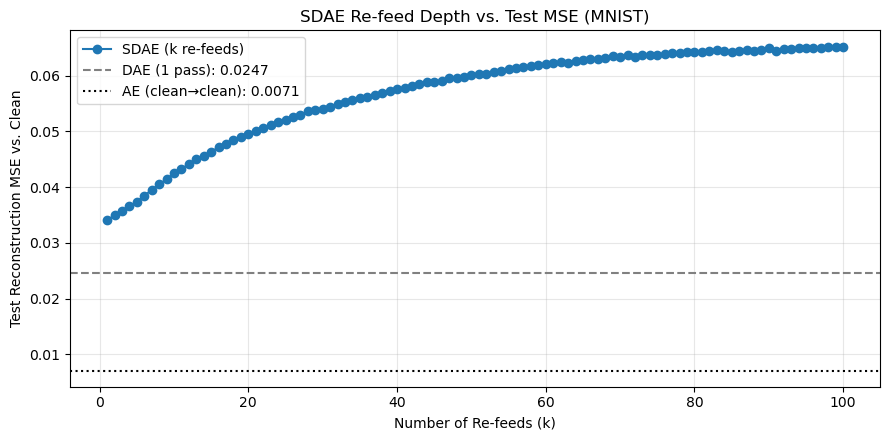

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from typing import Dict, List

# ----------------------------
# Noise
# ----------------------------
def add_noise(img, noise_factor=0.81):
    """
    Add Gaussian noise to an input image tensor in [0,1], then clamp.
    """
    noisy = img + noise_factor * torch.randn_like(img)
    return torch.clamp(noisy, 0., 1.)

# ----------------------------
# Data
# ----------------------------
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# ----------------------------
# Model
# ----------------------------
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# ----------------------------
# Utilities
# ----------------------------
def forward_k(model: nn.Module, x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Feed 'x' through 'model' k times (re-feeds).
    """
    for _ in range(k):
        x = model(x)
    return x

@torch.no_grad()
def batch_mse(a, b):
    return ((a - b) ** 2).mean().item()

def evaluate(model: nn.Module,
             loader,
             *,
             denoising: bool,
             re_feeds: int = 1,
             noise_factor: float = 0.81,
             device: torch.device = torch.device("cpu"),
             criterion = nn.MSELoss()) -> float:
    """
    Evaluate reconstruction MSE against the clean target images.
    - If denoising=True, inputs = add_noise(clean), targets = clean.
    - If denoising=False, inputs = clean, targets = clean.
    - The model output is forward_k(model, inputs, re_feeds).
    """
    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device, non_blocking=True)
            inputs = add_noise(imgs, noise_factor) if denoising else imgs
            recon = forward_k(model, inputs, re_feeds)
            loss = criterion(recon, imgs)
            bsz = imgs.size(0)
            total += loss.item() * bsz
            count += bsz
    return total / max(count, 1)

# ----------------------------
# Setup 3 models
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Stacked denoising AE (SDAE): trained with k>1 re-feeds on noisy inputs
sdae = DenoisingAutoencoder().to(device)

# 2) Single-pass denoising AE (DAE): trained 1 pass on noisy inputs
dae  = DenoisingAutoencoder().to(device)

# 3) Plain AE: trained 1 pass on clean inputs
ae   = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
opt_sdae = optim.Adam(sdae.parameters(), lr=1e-3)
opt_dae  = optim.Adam(dae.parameters(),  lr=1e-3)
opt_ae   = optim.Adam(ae.parameters(),   lr=1e-3)

noise_factor = 0.81
epochs = 10
stack_k_train = 5     # SDAE training re-feeds
stack_k_eval  = 5     # SDAE default eval re-feeds

# Iterative loss hyperparams (SDAE only)
lambda_stay = 0.5
stay_eps    = 1e-2
smooth_tau  = 20.0          # set None for a hard indicator
# Uniform weights across k training steps
# w_rec_sdae = torch.ones(stack_k_train, device=device)
# or emphasize later steps:
w_rec_sdae = torch.linspace(0.75, 1.25, steps=stack_k_train, device=device)



# ----------------------------
# Training loop
# ----------------------------
for epoch in range(1, epochs + 1):
    sdae.train(); dae.train(); ae.train()
    train_sum = {"sdae":0.0, "dae":0.0, "ae":0.0}
    train_cnt = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        noisy = add_noise(imgs, noise_factor)

        bsz = imgs.size(0)

        # ---- SDAE: noisy -> clean with k re-feeds
        ys_sdae = trajectory(sdae, noisy, stack_k_train)  # [y1,...,yk]
        loss_sdae, sdae_metrics = iterative_loss(
            ys_sdae, imgs,
            w_rec=w_rec_sdae,
            lambda_stay=lambda_stay,
            eps=stay_eps,
            smooth_tau=smooth_tau,
        )
        opt_sdae.zero_grad(set_to_none=True)
        loss_sdae.backward()
        opt_sdae.step()
        
        # For apples-to-apples train logging (MSE of final iterate vs clean)
        sdae_last = ys_sdae[-1].detach()
        loss_sdae_mse = criterion(sdae_last, imgs)


        # ---- DAE: noisy -> clean with 1 pass
        out_dae = dae(noisy)
        loss_dae = criterion(out_dae, imgs)
        opt_dae.zero_grad(set_to_none=True)
        loss_dae.backward()
        opt_dae.step()

        # ---- AE: clean -> clean with 1 pass
        out_ae = ae(imgs)
        loss_ae = criterion(out_ae, imgs)
        opt_ae.zero_grad(set_to_none=True)
        loss_ae.backward()
        opt_ae.step()

        train_sum["sdae"] += loss_sdae_mse.item() * bsz
        train_sum["dae"]  += loss_dae.item()  * bsz
        train_sum["ae"]   += loss_ae.item()   * bsz
        train_cnt         += bsz

    # ---- Eval in natural regimes
    sdae_test = evaluate(sdae, test_loader, denoising=True,  re_feeds=stack_k_eval, noise_factor=noise_factor, device=device, criterion=criterion)
    dae_test  = evaluate(dae,  test_loader, denoising=True,  re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)
    ae_test   = evaluate(ae,   test_loader, denoising=False, re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)

    print(
        f"Epoch {epoch:02d} | "
        f"SDAE train_MSE={train_sum['sdae']/train_cnt:.4f} test_MSE={sdae_test:.4f} (k_train={stack_k_train}, k_eval={stack_k_eval}) | "
        f"DAE  train_MSE={train_sum['dae']/train_cnt:.4f}  test_MSE={dae_test:.4f} | "
        f"AE   train_MSE={train_sum['ae']/train_cnt:.4f}   test_MSE={ae_test:.4f}"
    )

# ----------------------------
# Iterative re-feed sweep for SDAE (k=1..100), with baselines
# ----------------------------
sdae.eval(); dae.eval(); ae.eval()

@torch.no_grad()
def sdae_k_sweep_mse(model: nn.Module,
                     loader,
                     ks: List[int],
                     noise_factor: float,
                     device: torch.device,
                     criterion = nn.MSELoss()) -> Dict[int, float]:
    """
    Compute test MSE for each k re-feeds on the *same* test set, denoising mode.
    Returns dict {k: mse}.
    """
    results = {}
    for k in ks:
        mse_k = evaluate(model, loader, denoising=True, re_feeds=k,
                         noise_factor=noise_factor, device=device, criterion=criterion)
        results[k] = mse_k
    return results

# Baseline reference (single numbers)
dae_mse  = evaluate(dae, test_loader, denoising=True,  re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)
ae_mse   = evaluate(ae,  test_loader, denoising=False, re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)

ks = list(range(1, 101))
sdae_curve = sdae_k_sweep_mse(sdae, test_loader, ks, noise_factor, device, criterion)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(ks, [sdae_curve[k] for k in ks], marker='o', linestyle='-', label='SDAE (k re-feeds)')
plt.axhline(dae_mse, color='gray', linestyle='--', label=f'DAE (1 pass): {dae_mse:.4f}')
plt.axhline(ae_mse,  color='black', linestyle=':',  label=f'AE (clean→clean): {ae_mse:.4f}')
plt.xlabel('Number of Re-feeds (k)')
plt.ylabel('Test Reconstruction MSE vs. Clean')
plt.title('SDAE Re-feed Depth vs. Test MSE (MNIST)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: quick sample visualization of denoising
# ----------------------------
@torch.no_grad()
def visualize_examples(model_sdae, model_dae, model_ae, loader, k_sdae=3, noise_factor=0.81, num_show=8):
    imgs, _ = next(iter(loader))
    imgs = imgs[:num_show].to(device)
    noisy = add_noise(imgs, noise_factor)

    deno_sdae = forward_k(model_sdae, noisy, k_sdae)
    deno_dae  = model_dae(noisy)
    recon_ae  = model_ae(imgs)

    # grid: clean | noisy | SDAE | DAE | AE (for reference)
    grid = torch.cat([imgs.cpu(), noisy.cpu(), deno_sdae.cpu(), deno_dae.cpu(), recon_ae.cpu()], dim=0)
    grid = make_grid(grid, nrow=num_show, pad_value=1.0)
    plt.figure(figsize=(num_show * 1.2, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"SDAE k={k_sdae} | DAE 1-pass | AE 1-pass")
    plt.show()

# Uncomment to visualize
# visualize_examples(sdae, dae, ae, test_loader, k_sdae=stack_k_eval, noise_factor=noise_factor, num_show=8)

In [15]:
from typing import List, Tuple
import torch
import torch.nn as nn

def iterative_loss(
    ys: List[torch.Tensor],
    x_target: torch.Tensor,
    *,
    w_rec: torch.Tensor,             # shape [k]
    lambda_stay: float = 0.5,        # penalize motion after goal is reached
    eps: float = 1e-2,               # goal threshold on squared L2
    smooth_tau: float | None = 20.0, # None => hard indicator
    use_cumulative_gate: bool = True,
    lambda_post: float = 0.0         # optional extra pull to x after goal
) -> Tuple[torch.Tensor, dict]:
    """
    L_rec  = sum_{t=1..k}     w_t * ||y_t - x||^2
    L_stay = sum_{t=1..k-1} λ_stay * G_t * ||y_{t+1} - y_t||^2
        where G_t is a gate that is 1 once the goal has been reached at or before t.
        - If use_cumulative_gate=True (recommended): G_t = 1 - Π_{s=1..t} (1 - r_s), r_s≈1 when ||y_s-x||^2 < eps
        - Else (original behavior): G_t = r_t (only current-step gate)

    Optional:
    L_post = λ_post * sum_{t=1..k} H_t * ||y_t - x||^2, with H_t = cumulative gate at step t.

    Returns (total_loss, metrics) reduced over batch by mean.
    """
    device = x_target.device
    dtype  = x_target.dtype
    k = len(ys)
    assert w_rec.numel() == k, f"w_rec must have length {k}"
    w_rec = w_rec.to(device=device, dtype=dtype)

    # ---------- per-step reconstruction distances D[:, t] = ||y_t - x||^2 ----------
    d2_list = [(yt - x_target).pow(2).flatten(1).sum(dim=1) for yt in ys]  # list of (B,)
    D = torch.stack(d2_list, dim=1)  # (B, k)

    # ---------- reconstruction term ----------
    L_rec = (w_rec.unsqueeze(0) * D).sum(dim=1).mean()

    # ---------- gates ----------
    eps_t = torch.as_tensor(eps, device=device, dtype=dtype)
    if smooth_tau is None:
        r = (D < eps_t).float()  # hard indicator per step (B, k)
        if use_cumulative_gate:
            # once-on, always-on
            G_full = torch.cumsum(r, dim=1).clamp(max=1.0)   # (B, k)
        else:
            G_full = r
    else:
        tau = torch.as_tensor(smooth_tau, device=device, dtype=dtype)
        r = torch.sigmoid(tau * (eps_t - D))                 # soft "is-close" prob (B, k)
        if use_cumulative_gate:
            # cumulative: 1 - Π (1 - r_s) up to step t
            G_full = 1.0 - torch.cumprod(1.0 - r, dim=1)     # (B, k)
        else:
            G_full = r

    # ---------- step sizes S[:, t] = ||y_{t+1} - y_t||^2 for t=1..k-1 ----------
    steps = [(ys[t+1] - ys[t]).pow(2).flatten(1).sum(dim=1) for t in range(k - 1)]  # list of (B,)
    if steps:
        S = torch.stack(steps, dim=1)          # (B, k-1)
        G = G_full[:, :-1]                     # align gate at step t to movement from t -> t+1
        L_stay = (lambda_stay * (G * S).sum(dim=1)).mean()
    else:
        L_stay = torch.zeros((), device=device, dtype=dtype)

    # ---------- optional post-goal extra pull to x (usually unnecessary; set λ_post>0 if desired) ----------
    if lambda_post > 0.0:
        L_post = (lambda_post * (G_full * D).sum(dim=1)).mean()
    else:
        L_post = torch.zeros((), device=device, dtype=dtype)

    total = L_rec + L_stay + L_post

    metrics = {
        "loss_total": total.detach(),
        "loss_rec":   L_rec.detach(),
        "loss_stay":  L_stay.detach(),
        "loss_post":  L_post.detach(),
        "gate_mean":  G_full.mean().detach(),  # how often we're in 'after-goal' regime
        "gate_last":  G_full[:, -1].mean().detach(),  # % batches that have reached goal by final step
    }
    return total, metrics


Epoch 01 | SDAE train_MSE=0.0700 test_MSE=0.0676 (k_train=5, k_eval=5) | DAE  train_MSE=0.0621  test_MSE=0.0463 | AE   train_MSE=0.0440   test_MSE=0.0238
Epoch 02 | SDAE train_MSE=0.0677 test_MSE=0.0676 (k_train=5, k_eval=5) | DAE  train_MSE=0.0403  test_MSE=0.0365 | AE   train_MSE=0.0195   test_MSE=0.0154
Epoch 03 | SDAE train_MSE=0.0650 test_MSE=0.0607 (k_train=5, k_eval=5) | DAE  train_MSE=0.0343  test_MSE=0.0321 | AE   train_MSE=0.0143   test_MSE=0.0126
Epoch 04 | SDAE train_MSE=0.0587 test_MSE=0.0558 (k_train=5, k_eval=5) | DAE  train_MSE=0.0314  test_MSE=0.0300 | AE   train_MSE=0.0118   test_MSE=0.0107
Epoch 05 | SDAE train_MSE=0.0531 test_MSE=0.0506 (k_train=5, k_eval=5) | DAE  train_MSE=0.0295  test_MSE=0.0289 | AE   train_MSE=0.0102   test_MSE=0.0095
Epoch 06 | SDAE train_MSE=0.0475 test_MSE=0.0452 (k_train=5, k_eval=5) | DAE  train_MSE=0.0283  test_MSE=0.0274 | AE   train_MSE=0.0091   test_MSE=0.0086
Epoch 07 | SDAE train_MSE=0.0444 test_MSE=0.0437 (k_train=5, k_eval=5) | DAE

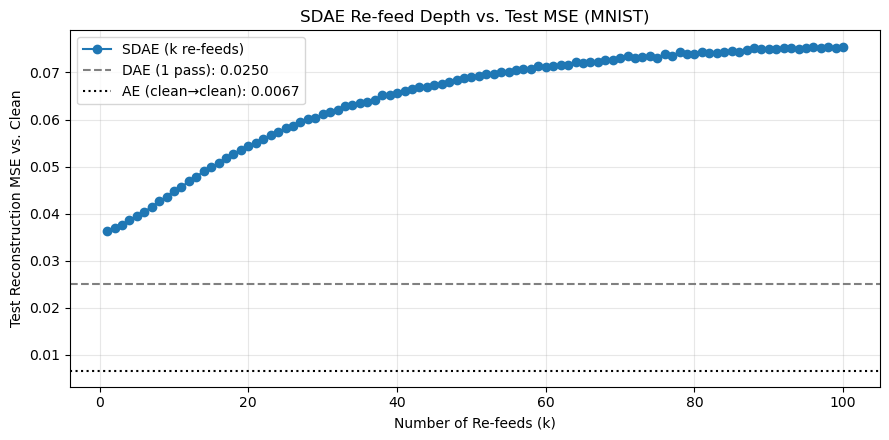

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from typing import Dict, List

# ----------------------------
# Noise
# ----------------------------
def add_noise(img, noise_factor=0.81):
    """
    Add Gaussian noise to an input image tensor in [0,1], then clamp.
    """
    noisy = img + noise_factor * torch.randn_like(img)
    return torch.clamp(noisy, 0., 1.)

# ----------------------------
# Data
# ----------------------------
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# ----------------------------
# Model
# ----------------------------
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# ----------------------------
# Utilities
# ----------------------------
def forward_k(model: nn.Module, x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Feed 'x' through 'model' k times (re-feeds).
    """
    for _ in range(k):
        x = model(x)
    return x

@torch.no_grad()
def batch_mse(a, b):
    return ((a - b) ** 2).mean().item()

def evaluate(model: nn.Module,
             loader,
             *,
             denoising: bool,
             re_feeds: int = 1,
             noise_factor: float = 0.81,
             device: torch.device = torch.device("cpu"),
             criterion = nn.MSELoss()) -> float:
    """
    Evaluate reconstruction MSE against the clean target images.
    - If denoising=True, inputs = add_noise(clean), targets = clean.
    - If denoising=False, inputs = clean, targets = clean.
    - The model output is forward_k(model, inputs, re_feeds).
    """
    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device, non_blocking=True)
            inputs = add_noise(imgs, noise_factor) if denoising else imgs
            recon = forward_k(model, inputs, re_feeds)
            loss = criterion(recon, imgs)
            bsz = imgs.size(0)
            total += loss.item() * bsz
            count += bsz
    return total / max(count, 1)

# ----------------------------
# Setup 3 models
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Stacked denoising AE (SDAE): trained with k>1 re-feeds on noisy inputs
sdae = DenoisingAutoencoder().to(device)

# 2) Single-pass denoising AE (DAE): trained 1 pass on noisy inputs
dae  = DenoisingAutoencoder().to(device)

# 3) Plain AE: trained 1 pass on clean inputs
ae   = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
opt_sdae = optim.Adam(sdae.parameters(), lr=1e-3)
opt_dae  = optim.Adam(dae.parameters(),  lr=1e-3)
opt_ae   = optim.Adam(ae.parameters(),   lr=1e-3)

noise_factor = 0.81
epochs = 10
stack_k_train = 5     # SDAE training re-feeds
stack_k_eval  = 5     # SDAE default eval re-feeds

# Iterative loss hyperparams (SDAE only)
lambda_stay = 0.5
stay_eps    = 1e-2
smooth_tau  = 20.0          # set None for a hard indicator
# Uniform weights across k training steps
# w_rec_sdae = torch.ones(stack_k_train, device=device)
# or emphasize later steps:
w_rec_sdae = torch.linspace(0.75, 1.25, steps=stack_k_train, device=device)



# ----------------------------
# Training loop
# ----------------------------
for epoch in range(1, epochs + 1):
    sdae.train(); dae.train(); ae.train()
    train_sum = {"sdae":0.0, "dae":0.0, "ae":0.0}
    train_cnt = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        noisy = add_noise(imgs, noise_factor)

        bsz = imgs.size(0)

        # ---- SDAE: noisy -> clean with k re-feeds
        ys_sdae = trajectory(sdae, noisy, stack_k_train)  # [y1,...,yk]
        loss_sdae, sdae_metrics = iterative_loss(
            ys_sdae, imgs,
            w_rec=w_rec_sdae,
            lambda_stay=lambda_stay,
            eps=stay_eps,
            smooth_tau=smooth_tau,
        )
        opt_sdae.zero_grad(set_to_none=True)
        loss_sdae.backward()
        opt_sdae.step()
        
        # For apples-to-apples train logging (MSE of final iterate vs clean)
        sdae_last = ys_sdae[-1].detach()
        loss_sdae_mse = criterion(sdae_last, imgs)


        # ---- DAE: noisy -> clean with 1 pass
        out_dae = dae(noisy)
        loss_dae = criterion(out_dae, imgs)
        opt_dae.zero_grad(set_to_none=True)
        loss_dae.backward()
        opt_dae.step()

        # ---- AE: clean -> clean with 1 pass
        out_ae = ae(imgs)
        loss_ae = criterion(out_ae, imgs)
        opt_ae.zero_grad(set_to_none=True)
        loss_ae.backward()
        opt_ae.step()

        train_sum["sdae"] += loss_sdae_mse.item() * bsz
        train_sum["dae"]  += loss_dae.item()  * bsz
        train_sum["ae"]   += loss_ae.item()   * bsz
        train_cnt         += bsz

    # ---- Eval in natural regimes
    sdae_test = evaluate(sdae, test_loader, denoising=True,  re_feeds=stack_k_eval, noise_factor=noise_factor, device=device, criterion=criterion)
    dae_test  = evaluate(dae,  test_loader, denoising=True,  re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)
    ae_test   = evaluate(ae,   test_loader, denoising=False, re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)

    print(
        f"Epoch {epoch:02d} | "
        f"SDAE train_MSE={train_sum['sdae']/train_cnt:.4f} test_MSE={sdae_test:.4f} (k_train={stack_k_train}, k_eval={stack_k_eval}) | "
        f"DAE  train_MSE={train_sum['dae']/train_cnt:.4f}  test_MSE={dae_test:.4f} | "
        f"AE   train_MSE={train_sum['ae']/train_cnt:.4f}   test_MSE={ae_test:.4f}"
    )

# ----------------------------
# Iterative re-feed sweep for SDAE (k=1..100), with baselines
# ----------------------------
sdae.eval(); dae.eval(); ae.eval()

@torch.no_grad()
def sdae_k_sweep_mse(model: nn.Module,
                     loader,
                     ks: List[int],
                     noise_factor: float,
                     device: torch.device,
                     criterion = nn.MSELoss()) -> Dict[int, float]:
    """
    Compute test MSE for each k re-feeds on the *same* test set, denoising mode.
    Returns dict {k: mse}.
    """
    results = {}
    for k in ks:
        mse_k = evaluate(model, loader, denoising=True, re_feeds=k,
                         noise_factor=noise_factor, device=device, criterion=criterion)
        results[k] = mse_k
    return results

# Baseline reference (single numbers)
dae_mse  = evaluate(dae, test_loader, denoising=True,  re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)
ae_mse   = evaluate(ae,  test_loader, denoising=False, re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)

ks = list(range(1, 101))
sdae_curve = sdae_k_sweep_mse(sdae, test_loader, ks, noise_factor, device, criterion)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(ks, [sdae_curve[k] for k in ks], marker='o', linestyle='-', label='SDAE (k re-feeds)')
plt.axhline(dae_mse, color='gray', linestyle='--', label=f'DAE (1 pass): {dae_mse:.4f}')
plt.axhline(ae_mse,  color='black', linestyle=':',  label=f'AE (clean→clean): {ae_mse:.4f}')
plt.xlabel('Number of Re-feeds (k)')
plt.ylabel('Test Reconstruction MSE vs. Clean')
plt.title('SDAE Re-feed Depth vs. Test MSE (MNIST)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: quick sample visualization of denoising
# ----------------------------
@torch.no_grad()
def visualize_examples(model_sdae, model_dae, model_ae, loader, k_sdae=3, noise_factor=0.81, num_show=8):
    imgs, _ = next(iter(loader))
    imgs = imgs[:num_show].to(device)
    noisy = add_noise(imgs, noise_factor)

    deno_sdae = forward_k(model_sdae, noisy, k_sdae)
    deno_dae  = model_dae(noisy)
    recon_ae  = model_ae(imgs)

    # grid: clean | noisy | SDAE | DAE | AE (for reference)
    grid = torch.cat([imgs.cpu(), noisy.cpu(), deno_sdae.cpu(), deno_dae.cpu(), recon_ae.cpu()], dim=0)
    grid = make_grid(grid, nrow=num_show, pad_value=1.0)
    plt.figure(figsize=(num_show * 1.2, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"SDAE k={k_sdae} | DAE 1-pass | AE 1-pass")
    plt.show()

# Uncomment to visualize
# visualize_examples(sdae, dae, ae, test_loader, k_sdae=stack_k_eval, noise_factor=noise_factor, num_show=8)

In [18]:
from typing import List, Tuple

def trajectory(model: nn.Module, x0: torch.Tensor, k: int):
    """
    Iterative trajectory: y1 = f*x0), yk = f(k-1).
    Returns [y1, y2, ..., yk] 
    """
    
    ys = []
    y = model(x0)
    ys.append(y)
    for _ in range(1,k):
        y = model(y)
        ys.append(y)
    return ys

def iterative_loss(
    ys: List[torch.Tensor],
    x_target: torch.Tensor,
    *,
    w_rec: torch.Tensor,
    lambda_stay = float(1.0),
    eps: float = 1e-3,
    smooth_tau: float | None = 20.00):
    
    """
    L_rec = sum(t = 1,... k) w_t * ||y_t - x || ^ 2
    L_stay = sum(t = 1... k-1) lambda_stay * 1[||y_t - x || ^ 2 < epsilon] * ||y_t+1 = y_t||^2
    Returns (total_loss, metrics) Which reduces over batch by the mean.
    """
    device = x_target.device
    dtype = x_target.dtype
    k = len(ys)
    assert w_rec.numel() == k 

    # L_rec
    rec_terms = []
    for wt, yt in zip(w_rec, ys):
        d2 = (yt - x_target).pow(2).flatten(1).sum(dim = 1)
        rec_terms.append(wt*d2)
    L_rec_per_ex = torch.stack(rec_terms, dim = 1).sum(dim=1)
    L_rec = L_rec_per_ex.mean()

    stay_terms = []
    eps_t = torch.as_tensor(eps, device = device, dtype = dtype)
    for t in range(k-1):
        yt, t_t1 = ys[t], ys[t+1]
        dtx2 = (yt - x_target).pow(2).flatten(1).sum(dim = 1)
        if smooth_tau is None:
            ind = (dtx2 < eps_t).float()
        else:
            tau = torch.as_tensor(smooth_tau, device = device, dtype = dtype)
            ind = torch.sigmoid(tau * (eps_t - dtx2))
        step2 = (yt-yt).pow(2).flatten(1).sum(dim=1)
        stay_terms.append(ind * step2)

    if stay_terms:
        L_stay_per_ex = torch.stack(stay_terms, dim = 1).sum(dim=1)
        L_stay = (lambda_stay * L_stay_per_ex).mean()
        mean_ind = torch.stack(stay_terms, dim = 1).mean().detach()
    else:
        L_stay = torch.zeros((), device = device, dtype = dtype)
        mean_ind = torch.tensor(0.0)

    total = L_rec + L_stay
    metrics = {
        "loss_total": total.detach(),
        "loss_rec": L_rec.detach(),
        "loss_stay": L_stay.detach(),
        "mean_indicator": mean_ind}
        
    return total, metrics

In [23]:
from typing import List, Tuple, Optional
import torch

def iterative_loss(
    ys: List[torch.Tensor],
    x_target: torch.Tensor,
    *,
    w_rec: torch.Tensor,                 # shape [k]
    lambda_stay: float = 1.0,            # your original gated stay term
    eps: float = 1e-3,
    smooth_tau: Optional[float] = 20.0,  # None => hard gate
    # NEW (both optional; set to 0.0 to disable):
    lambda_step: float = 0.0,            # ungated step budget (encourage spreading work)
    lambda_improve: float = 0.0,         # monotonic improvement
    improve_margin: float = 0.0,         # delta in the ReLU
) -> Tuple[torch.Tensor, dict]:
    device = x_target.device
    dtype  = x_target.dtype
    k = len(ys)
    assert w_rec.numel() == k
    w_rec = w_rec.to(device=device, dtype=dtype)

    # Per-step squared distances: D[b, t] = ||y_t - x||^2
    D = torch.stack([(yt - x_target).pow(2).flatten(1).sum(1) for yt in ys], dim=1)  # (B,k)

    # 1) Reconstruction over steps
    L_rec = (w_rec.view(1, -1) * D).sum(dim=1).mean()

    # 2) Original "stay" term (gated near target)
    if k > 1:
        eps_t = torch.as_tensor(eps, device=device, dtype=dtype)
        if smooth_tau is None:
            r = (D < eps_t).float()  # (B,k)
        else:
            tau = torch.as_tensor(smooth_tau, device=device, dtype=dtype)
            r = torch.sigmoid(tau * (eps_t - D))  # smooth gate in (0,1)

        steps2 = torch.stack([(ys[t+1] - ys[t]).pow(2).flatten(1).sum(1) for t in range(k-1)], dim=1)  # (B,k-1)
        gate   = r[:, :-1]  # align gate at t to movement t->t+1
        L_stay = (lambda_stay * (gate * steps2).sum(dim=1)).mean()
    else:
        steps2 = None
        L_stay = torch.zeros((), device=device, dtype=dtype)

    # 3) NEW: ungated step-budget (penalize big single jumps)
    if lambda_step > 0.0 and k > 1:
        if steps2 is None:
            steps2 = torch.stack([(ys[t+1] - ys[t]).pow(2).flatten(1).sum(1) for t in range(k-1)], dim=1)
        L_step = (lambda_step * steps2.sum(dim=1)).mean()
    else:
        L_step = torch.zeros((), device=device, dtype=dtype)

    # 4) NEW: monotonic improvement (each step should not worsen)
    if lambda_improve > 0.0 and k > 1:
        dt = D[:, 1:] - D[:, :-1] + improve_margin  # (B,k-1)
        L_improve = (lambda_improve * torch.relu(dt).sum(dim=1)).mean()
    else:
        L_improve = torch.zeros((), device=device, dtype=dtype)

    total = L_rec + L_stay + L_step + L_improve
    metrics = {
        "loss_total":  total.detach(),
        "loss_rec":    L_rec.detach(),
        "loss_stay":   L_stay.detach(),
        "loss_step":   L_step.detach(),
        "loss_improve":L_improve.detach(),
        "mean_D_last": D[:, -1].mean().detach(),
    }
    return total, metrics


Epoch 01 | SDAE train_MSE=0.0697 test_MSE=0.0667 (k_train=5, k_eval=5) | DAE  train_MSE=0.0626  test_MSE=0.0463 | AE   train_MSE=0.0447   test_MSE=0.0238
Epoch 02 | SDAE train_MSE=0.0618 test_MSE=0.0600 (k_train=5, k_eval=5) | DAE  train_MSE=0.0403  test_MSE=0.0358 | AE   train_MSE=0.0197   test_MSE=0.0161
Epoch 03 | SDAE train_MSE=0.0558 test_MSE=0.0528 (k_train=5, k_eval=5) | DAE  train_MSE=0.0344  test_MSE=0.0323 | AE   train_MSE=0.0144   test_MSE=0.0124
Epoch 04 | SDAE train_MSE=0.0504 test_MSE=0.0474 (k_train=5, k_eval=5) | DAE  train_MSE=0.0317  test_MSE=0.0301 | AE   train_MSE=0.0116   test_MSE=0.0106
Epoch 05 | SDAE train_MSE=0.0464 test_MSE=0.0450 (k_train=5, k_eval=5) | DAE  train_MSE=0.0297  test_MSE=0.0287 | AE   train_MSE=0.0100   test_MSE=0.0094
Epoch 06 | SDAE train_MSE=0.0435 test_MSE=0.0431 (k_train=5, k_eval=5) | DAE  train_MSE=0.0284  test_MSE=0.0273 | AE   train_MSE=0.0089   test_MSE=0.0084
Epoch 07 | SDAE train_MSE=0.0418 test_MSE=0.0407 (k_train=5, k_eval=5) | DAE

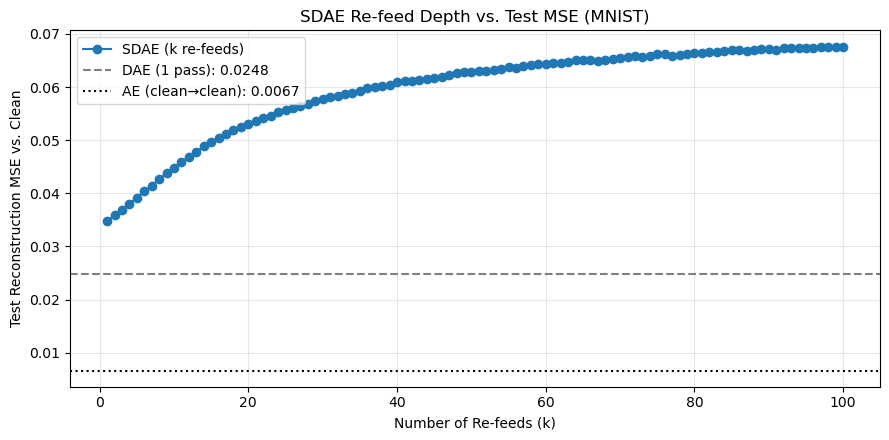

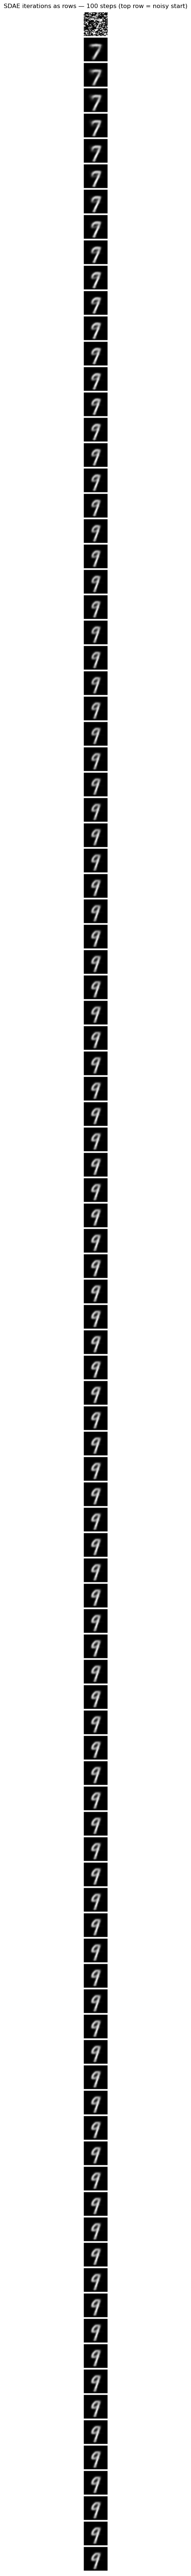

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from typing import Dict, List

# ----------------------------
# Noise
# ----------------------------
def add_noise(img, noise_factor=0.81):
    """
    Add Gaussian noise to an input image tensor in [0,1], then clamp.
    """
    noisy = img + noise_factor * torch.randn_like(img)
    return torch.clamp(noisy, 0., 1.)

# ----------------------------
# Data
# ----------------------------
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# ----------------------------
# Model
# ----------------------------
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# ----------------------------
# Utilities
# ----------------------------
def forward_k(model: nn.Module, x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Feed 'x' through 'model' k times (re-feeds).
    """
    for _ in range(k):
        x = model(x)
    return x

@torch.no_grad()
def batch_mse(a, b):
    return ((a - b) ** 2).mean().item()

def evaluate(model: nn.Module,
             loader,
             *,
             denoising: bool,
             re_feeds: int = 1,
             noise_factor: float = 0.81,
             device: torch.device = torch.device("cpu"),
             criterion = nn.MSELoss()) -> float:
    """
    Evaluate reconstruction MSE against the clean target images.
    - If denoising=True, inputs = add_noise(clean), targets = clean.
    - If denoising=False, inputs = clean, targets = clean.
    - The model output is forward_k(model, inputs, re_feeds).
    """
    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device, non_blocking=True)
            inputs = add_noise(imgs, noise_factor) if denoising else imgs
            recon = forward_k(model, inputs, re_feeds)
            loss = criterion(recon, imgs)
            bsz = imgs.size(0)
            total += loss.item() * bsz
            count += bsz
    return total / max(count, 1)

# ----------------------------
# Setup 3 models
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Stacked denoising AE (SDAE): trained with k>1 re-feeds on noisy inputs
sdae = DenoisingAutoencoder().to(device)

# 2) Single-pass denoising AE (DAE): trained 1 pass on noisy inputs
dae  = DenoisingAutoencoder().to(device)

# 3) Plain AE: trained 1 pass on clean inputs
ae   = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
opt_sdae = optim.Adam(sdae.parameters(), lr=1e-3)
opt_dae  = optim.Adam(dae.parameters(),  lr=1e-3)
opt_ae   = optim.Adam(ae.parameters(),   lr=1e-3)

noise_factor = 0.81
epochs = 10
stack_k_train = 5     # SDAE training re-feeds
stack_k_eval  = 5     # SDAE default eval re-feeds

# Iterative loss hyperparams (SDAE only)
lambda_stay = 0.5
stay_eps    = 1e-2
smooth_tau  = 0          # set None for a hard indicator
# Uniform weights across k training steps
# w_rec_sdae = torch.ones(stack_k_train, device=device)
# or emphasize later steps:
w_rec_sdae = torch.linspace(0.75, 1.25, steps=stack_k_train, device=device)



# ----------------------------
# Training loop
# ----------------------------
for epoch in range(1, epochs + 1):
    sdae.train(); dae.train(); ae.train()
    train_sum = {"sdae":0.0, "dae":0.0, "ae":0.0}
    train_cnt = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        noisy = add_noise(imgs, noise_factor)

        bsz = imgs.size(0)

        # ---- SDAE: noisy -> clean with k re-feeds
        ys_sdae = trajectory(sdae, noisy, stack_k_train)  # [y1,...,yk]
        loss_sdae, sdae_metrics = iterative_loss(
            ys_sdae, imgs,
            w_rec=w_rec_sdae,
            lambda_stay=lambda_stay,
            eps=stay_eps,
            smooth_tau=smooth_tau,
        )
        opt_sdae.zero_grad(set_to_none=True)
        loss_sdae.backward()
        opt_sdae.step()
        
        # For apples-to-apples train logging (MSE of final iterate vs clean)
        sdae_last = ys_sdae[-1].detach()
        loss_sdae_mse = criterion(sdae_last, imgs)


        # ---- DAE: noisy -> clean with 1 pass
        out_dae = dae(noisy)
        loss_dae = criterion(out_dae, imgs)
        opt_dae.zero_grad(set_to_none=True)
        loss_dae.backward()
        opt_dae.step()

        # ---- AE: clean -> clean with 1 pass
        out_ae = ae(imgs)
        loss_ae = criterion(out_ae, imgs)
        opt_ae.zero_grad(set_to_none=True)
        loss_ae.backward()
        opt_ae.step()

        train_sum["sdae"] += loss_sdae_mse.item() * bsz
        train_sum["dae"]  += loss_dae.item()  * bsz
        train_sum["ae"]   += loss_ae.item()   * bsz
        train_cnt         += bsz

    # ---- Eval in natural regimes
    sdae_test = evaluate(sdae, test_loader, denoising=True,  re_feeds=stack_k_eval, noise_factor=noise_factor, device=device, criterion=criterion)
    dae_test  = evaluate(dae,  test_loader, denoising=True,  re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)
    ae_test   = evaluate(ae,   test_loader, denoising=False, re_feeds=1,               noise_factor=noise_factor, device=device, criterion=criterion)

    print(
        f"Epoch {epoch:02d} | "
        f"SDAE train_MSE={train_sum['sdae']/train_cnt:.4f} test_MSE={sdae_test:.4f} (k_train={stack_k_train}, k_eval={stack_k_eval}) | "
        f"DAE  train_MSE={train_sum['dae']/train_cnt:.4f}  test_MSE={dae_test:.4f} | "
        f"AE   train_MSE={train_sum['ae']/train_cnt:.4f}   test_MSE={ae_test:.4f}"
    )

# ----------------------------
# Iterative re-feed sweep for SDAE (k=1..100), with baselines
# ----------------------------
sdae.eval(); dae.eval(); ae.eval()

@torch.no_grad()
def sdae_k_sweep_mse(model: nn.Module,
                     loader,
                     ks: List[int],
                     noise_factor: float,
                     device: torch.device,
                     criterion = nn.MSELoss()) -> Dict[int, float]:
    """
    Compute test MSE for each k re-feeds on the *same* test set, denoising mode.
    Returns dict {k: mse}.
    """
    results = {}
    for k in ks:
        mse_k = evaluate(model, loader, denoising=True, re_feeds=k,
                         noise_factor=noise_factor, device=device, criterion=criterion)
        results[k] = mse_k
    return results

# Baseline reference (single numbers)
dae_mse  = evaluate(dae, test_loader, denoising=True,  re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)
ae_mse   = evaluate(ae,  test_loader, denoising=False, re_feeds=1, noise_factor=noise_factor, device=device, criterion=criterion)

ks = list(range(1, 101))
sdae_curve = sdae_k_sweep_mse(sdae, test_loader, ks, noise_factor, device, criterion)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(ks, [sdae_curve[k] for k in ks], marker='o', linestyle='-', label='SDAE (k re-feeds)')
plt.axhline(dae_mse, color='gray', linestyle='--', label=f'DAE (1 pass): {dae_mse:.4f}')
plt.axhline(ae_mse,  color='black', linestyle=':',  label=f'AE (clean→clean): {ae_mse:.4f}')
plt.xlabel('Number of Re-feeds (k)')
plt.ylabel('Test Reconstruction MSE vs. Clean')
plt.title('SDAE Re-feed Depth vs. Test MSE (MNIST)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: quick sample visualization of denoising
# ----------------------------
@torch.no_grad()
def visualize_examples(model_sdae, model_dae, model_ae, loader, k_sdae=3, noise_factor=0.81, num_show=8):
    imgs, _ = next(iter(loader))
    imgs = imgs[:num_show].to(device)
    noisy = add_noise(imgs, noise_factor)

    deno_sdae = forward_k(model_sdae, noisy, k_sdae)
    deno_dae  = model_dae(noisy)
    recon_ae  = model_ae(imgs)

    # grid: clean | noisy | SDAE | DAE | AE (for reference)
    grid = torch.cat([imgs.cpu(), noisy.cpu(), deno_sdae.cpu(), deno_dae.cpu(), recon_ae.cpu()], dim=0)
    grid = make_grid(grid, nrow=num_show, pad_value=1.0)
    plt.figure(figsize=(num_show * 1.2, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"SDAE k={k_sdae} | DAE 1-pass | AE 1-pass")
    plt.show()

@torch.no_grad()
def visualize_sdae_iterations_rows(
    model_sdae,
    loader,
    k_rows: int = 100,
    noise_factor: float = 0.81,
    include_noisy: bool = True,   # top row shows the starting noisy image
    row_scale: float = 1.0        # increase to make each row taller
):
    model_sdae.eval()
    imgs, _ = next(iter(loader))
    img = imgs[:1].to(device)                     # single sample (1,1,28,28)

    y = add_noise(img, noise_factor)
    tiles = []
    if include_noisy:
        tiles.append(y.squeeze(0).cpu())          # t=0 (noisy start)

    # collect y1..y_k_rows (each becomes one row)
    for _ in range(k_rows):
        y = model_sdae(y)
        tiles.append(y.squeeze(0).cpu())

    # one image per row (nrow=1 => tall figure)
    grid = make_grid(tiles, nrow=1, pad_value=1.0)

    plt.figure(figsize=(2.2, max(6, len(tiles) * row_scale)))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    title = f"SDAE iterations as rows — {k_rows} steps"
    if include_noisy:
        title += " (top row = noisy start)"
    plt.title(title)
    plt.show()

visualize_sdae_iterations_rows(
    sdae, test_loader,
    k_rows=100,
    noise_factor=noise_factor,
    include_noisy=True,
    row_scale=0.9   # bump up if you want bigger rows
)

